# DriftGuard — Windowed KNN

## About This Notebook

In the previous notebook, I implemented and evaluated an incremental Gaussian Naive Bayes model on the sequential Electricity stream.

In this notebook, I will study K-Nearest Neighbors (KNN) in the same streaming setting.

Unlike Gaussian Naive Bayes, KNN does not learn a fixed set of statistical parameters. Instead, it makes predictions by comparing a new observation with previously observed training examples.

For a streaming problem, keeping every historical observation indefinitely is not practical and can also make the model less responsive to recent changes in the data.

I will therefore use a bounded sliding window that retains only recent observations.

### What I Will Do

I will:

- Load the Electricity dataset independently
- Recreate the same model-ready representation
- Recreate the same 500-observation sequential batches
- Implement a windowed KNN model
- Evaluate it using prequential evaluation
- Track performance across the stream
- Save the important results and visualizations

The resulting model will serve as the **non-adaptive windowed KNN baseline** for the later drift detection and adaptation experiments.

In [4]:
# Import pandas for working with the dataset
import pandas as pd

# Import NumPy for numerical operations
import numpy as np

# Import the ARFF loader for reading the Electricity dataset
from scipy.io import arff
# Load the raw Electricity dataset using the project file path
data, metadata = arff.loadarff(
    r"C:\Users\Pallavi Dahiya\drift_aware_classification\data\raw\elecNormNew.arff"
)
# Convert the loaded data into a Pandas DataFrame
df = pd.DataFrame(data)

# Display the dataset dimensions
print("Dataset shape:", df.shape)

Dataset shape: (45312, 9)


In [5]:
# Create a copy for model preparation
model_data = df.copy()

# Decode the day values from bytes into strings
model_data["day"] = model_data["day"].str.decode("utf-8")

# Decode the target values from bytes into strings
model_data["class"] = model_data["class"].str.decode("utf-8")

# Convert day categories into binary features
model_data = pd.get_dummies(
    model_data,
    columns=["day"],
    dtype=int
)

# Convert the target classes into numerical labels
model_data["class"] = model_data["class"].map({
    "DOWN": 0,
    "UP": 1
})

# Display the model-ready dimensions
print("Model-ready shape:", model_data.shape)

Model-ready shape: (45312, 15)


In [6]:
# Set the sequential batch size established in Notebook 03
batch_size = 500

# Create an empty list for the sequential batches
batches = []

# Split the data while preserving its original order
for start in range(0, len(model_data), batch_size):
    end = start + batch_size
    batches.append(model_data.iloc[start:end].copy())

# Display the streaming configuration
print("Number of batches:", len(batches))
print("First batch size:", len(batches[0]))
print("Final batch size:", len(batches[-1]))

Number of batches: 91
First batch size: 500
Final batch size: 312


## Defining the KNN Memory Window

### Why

KNN makes predictions by comparing new observations with previously observed examples.

Unlike Gaussian Naive Bayes, it does not summarize historical data into running statistics. If I retained every observation, the amount of stored data would continue growing throughout the stream.

I will therefore use a bounded sliding window so that the model retains only recent observations.

### Window Size Decision

I will use a **2,000-observation window** as the initial KNN baseline.

The streaming batch size is **500 observations**, so:

- **500 observations = 1 recent batch**
- **1,000 observations = 2 recent batches**
- **2,000 observations = 4 recent batches**
- **5,000 observations = 10 recent batches**
- **10,000 observations = 20 recent batches**

The selected 2,000-observation window therefore represents the most recent **4 batches**.

The four-batch relationship is not based on a claim that four batches are inherently optimal. It is simply the result of the selected 2,000-observation window and the fixed 500-observation batch size.

### Trade-off

The window size controls how much historical information KNN retains:

| Window Size | Recent Batches | Expected Behavior |
| --- | ---: | --- |
| 500 | 1 | Highly responsive, but fewer neighbors |
| 1,000 | 2 | More responsive, with limited history |
| **2,000** | **4** | Balanced baseline |
| 5,000 | 10 | More stable, but slower to forget older patterns |
| 10,000 | 20 | Stronger historical memory, but potentially less responsive to drift |

A smaller window can respond more quickly to recent changes but may produce less stable predictions because fewer examples are available.

A larger window provides more historical examples and potentially more stable predictions, but it can retain outdated patterns for longer.

### Decision

I will use **2,000 observations** as the initial KNN baseline.

I will treat this as a **documented experimental configuration**, not as a value optimized to maximize accuracy.

If needed, I will later perform a small sensitivity analysis using **1,000, 2,000, and 5,000 observations** to determine whether the project's conclusions depend strongly on the selected window size.

### Role in Drift Adaptation

During normal operation, the non-adaptive windowed KNN model will retain the most recent **2,000 observations**.

Later, when Page-Hinkley detects a significant change in the prediction-error stream, the adaptive KNN model will respond by removing older observations more aggressively.

This will allow me to compare whether explicit drift-triggered adaptation improves KNN's response to changing data compared with the non-adaptive windowed baseline.

## Initializing the Windowed KNN Model

### Why

I now have a tested windowed KNN implementation.

I will initialize it with the 2,000-observation memory window selected earlier.

The first batch will be used as a warm-up batch so that the model has historical observations before prequential evaluation begins.

In [8]:
# Add the project's src directory to the Python path
import sys
sys.path.insert(
    0,
    r"C:\Users\Pallavi Dahiya\drift_aware_classification\src"
)

# Import the reusable windowed KNN implementation
from driftaware.models.windowed_knn import WindowedKNN

# Initialize the windowed KNN model
model = WindowedKNN(
    window_size=2000,
    n_neighbors=5
)

# Display the selected KNN configuration
print("KNN window size:", model.window_size)
print("Number of neighbors:", model.n_neighbors)

KNN window size: 2000
Number of neighbors: 5


## Warming Up the Windowed KNN Model

### Why

The first batch will provide the initial reference observations for KNN.

I will not evaluate this batch because the model has no previous observations with which to make predictions.

From the second batch onward, I will use prequential evaluation: predict first, evaluate the predictions, and then add the current batch to the KNN window.

In [10]:
# Separate the first batch into predictors and target
X_warmup = batches[0].drop(columns=["class"])
y_warmup = batches[0]["class"]

# Add the first batch to the KNN reference window
model.update(X_warmup, y_warmup)

# Display the number of observations currently stored
print("Observations in KNN window:", len(model.X_window))

Observations in KNN window: 500


## Prequential Evaluation Across the Stream

### Why

The KNN model has now been initialized using the first batch.

I will evaluate the remaining batches sequentially. For each batch, I will first make predictions using the observations currently stored in the KNN window.

Only after evaluating those predictions will I add the current batch to the window.

This prevents the current batch from influencing its own predictions and keeps the evaluation consistent with the incremental Gaussian Naive Bayes experiment.

### What I Will Track

For each batch, I will record:

- Batch number
- Number of observations
- Accuracy
- F1 score
- Recall
- Number of observations currently retained by the KNN window

In [11]:
# Import the evaluation metrics
from sklearn.metrics import accuracy_score, f1_score, recall_score

# Create an empty list to store batch-level results
streaming_results = []

# Process every batch after the warm-up batch
for batch_number, batch in enumerate(batches[1:], start=2):

    # Separate the current batch into predictors and target
    X_batch = batch.drop(columns=["class"])
    y_batch = batch["class"]

    # Predict before adding the current batch to the KNN window
    predictions = model.predict(X_batch)

    # Calculate the evaluation metrics
    accuracy = accuracy_score(y_batch, predictions)
    f1 = f1_score(y_batch, predictions)
    recall = recall_score(y_batch, predictions)

    # Store the current batch results
    streaming_results.append({
        "batch": batch_number,
        "observations": len(batch),
        "accuracy": accuracy,
        "f1": f1,
        "recall": recall,
        "window_size": len(model.X_window)
    })

    # Update the KNN window after evaluation
    model.update(X_batch, y_batch)

# Convert the collected results into a DataFrame
streaming_results = pd.DataFrame(streaming_results)

# Display the first few batch results
streaming_results.head()

,batch,observations,accuracy,f1,recall,window_size
0,2,500,0.642,0.632444,0.581132,500
1,3,500,0.644,0.398649,0.578431,1000
2,4,500,0.772,0.716418,0.734694,1500
3,5,500,0.730,0.615385,0.490909,2000
4,6,500,0.696,0.608247,0.617801,2000


In [12]:
# Display the number of evaluated batches
print("Evaluated batches:", len(streaming_results))

# Display the total number of evaluated observations
print("Evaluated observations:", streaming_results["observations"].sum())

# Display the final evaluated batch
print("Final evaluated batch:", streaming_results["batch"].iloc[-1])

# Display the final KNN window size
print("Final KNN window size:", len(model.X_window))

Evaluated batches: 90
Evaluated observations: 44812
Final evaluated batch: 91
Final KNN window size: 2000


## Summarizing the Streaming Performance

### Finding

The windowed KNN model successfully processed the 90 post-warm-up batches in sequential order.

The model maintained a bounded reference window rather than retaining the complete history of the stream.

I will now calculate the overall streaming performance across all evaluated observations.

I will use observation-weighted metrics because the final batch contains 312 observations while the other batches contain 500.

In [13]:
# Calculate the total number of evaluated observations
total_observations = streaming_results["observations"].sum()

# Calculate the observation-weighted accuracy
weighted_accuracy = (
    streaming_results["accuracy"] * streaming_results["observations"]
).sum() / total_observations

# Calculate the observation-weighted F1 score
weighted_f1 = (
    streaming_results["f1"] * streaming_results["observations"]
).sum() / total_observations

# Calculate the observation-weighted recall
weighted_recall = (
    streaming_results["recall"] * streaming_results["observations"]
).sum() / total_observations

# Create a summary table
streaming_summary = pd.DataFrame({
    "metric": ["Accuracy", "F1", "Recall"],
    "score": [
        weighted_accuracy,
        weighted_f1,
        weighted_recall
    ]
})

# Display the overall streaming performance
streaming_summary

,metric,score
0,Accuracy,0.696978
1,F1,0.613304
2,Recall,0.596267


In [14]:
# Import os for directory and file path handling
import os

# Create the results directory if it does not already exist
os.makedirs("reports/results", exist_ok=True)

# Save the batch-level KNN results
streaming_results.to_csv(
    "reports/results/windowed_knn_streaming_results.csv",
    index=False
)

# Save the overall KNN performance
streaming_summary.to_csv(
    "reports/results/windowed_knn_streaming_summary.csv",
    index=False
)

# Confirm that the result files were saved
print("Streaming results saved successfully.")

Streaming results saved successfully.


## Visualizing KNN Performance Across the Stream

### Why

The overall metrics show the general performance of the windowed KNN model, but they do not show how performance changes as the stream progresses.

I will visualize accuracy, F1 score, and recall across the sequential batches.

This will help me identify periods of performance degradation that may later be relevant when evaluating drift detection and adaptation.

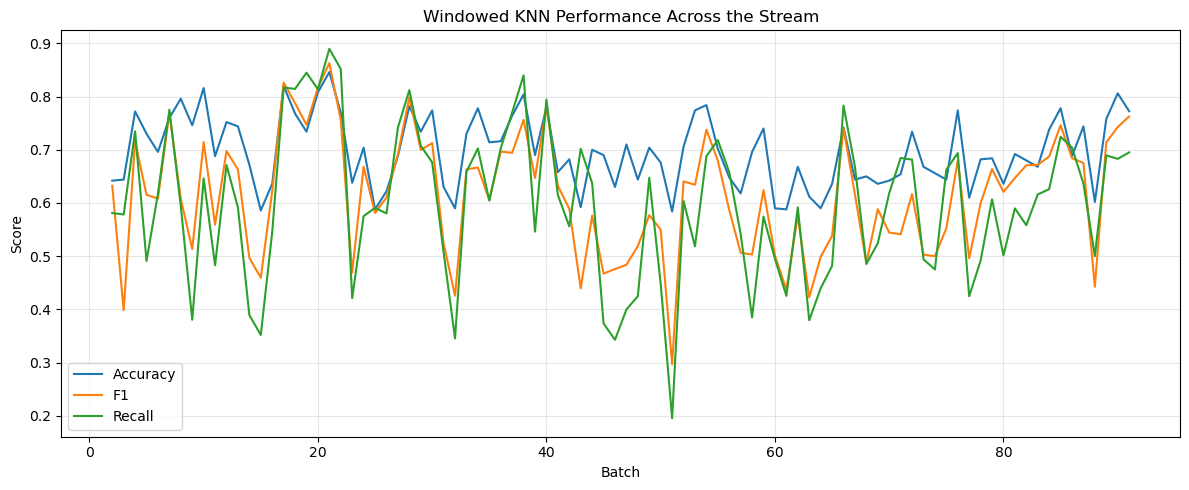

In [15]:
# Import Matplotlib for visualization
import matplotlib.pyplot as plt

# Import os for creating the figures directory
import os

# Create the figures directory if it does not already exist
os.makedirs("reports/figures", exist_ok=True)

# Create the performance figure
plt.figure(figsize=(12, 5))

# Plot accuracy across the sequential batches
plt.plot(
    streaming_results["batch"],
    streaming_results["accuracy"],
    label="Accuracy"
)

# Plot F1 score across the sequential batches
plt.plot(
    streaming_results["batch"],
    streaming_results["f1"],
    label="F1"
)

# Plot recall across the sequential batches
plt.plot(
    streaming_results["batch"],
    streaming_results["recall"],
    label="Recall"
)

# Add labels and a title
plt.xlabel("Batch")
plt.ylabel("Score")
plt.title("Windowed KNN Performance Across the Stream")

# Display the legend
plt.legend()

# Add a light grid
plt.grid(alpha=0.3)

# Adjust the layout
plt.tight_layout()

# Save the important project figure
plt.savefig(
    "reports/figures/windowed_knn_streaming_performance.png",
    dpi=300,
    bbox_inches="tight"
)

# Display the figure
plt.show()

## Finding

The batch-level performance shows how the windowed KNN model behaves as new observations arrive.

The model does not retain the complete historical stream. Instead, it continuously replaces older observations with newer ones once the 2,000-observation window is full.

This provides a useful non-adaptive streaming baseline for comparison with the incremental Gaussian Naive Bayes model.

I will use the observed performance pattern as a reference when I later introduce explicit drift detection and adaptation.

## Comparing the Streaming Baselines

### Why

I now have two non-adaptive streaming baselines:

- Incremental Gaussian Naive Bayes
- Windowed KNN

Both models were evaluated on the same sequential stream using the same 500-observation batches and the same prequential evaluation strategy.

I will compare their overall streaming performance before introducing explicit drift detection and adaptation.

In [20]:
# Import pandas for working with the results
import pandas as pd

# Load the Gaussian Naive Bayes summary from its actual saved location
nb_summary = pd.read_csv(
    r"C:\Users\Pallavi Dahiya\drift_aware_classification\reports\streaming\results\incremental_nb_streaming_summary.csv"
)

# Calculate the total number of KNN observations evaluated
total_observations = streaming_results["observations"].sum()

# Calculate the observation-weighted KNN accuracy
knn_accuracy = (
    streaming_results["accuracy"] * streaming_results["observations"]
).sum() / total_observations

# Calculate the observation-weighted KNN F1 score
knn_f1 = (
    streaming_results["f1"] * streaming_results["observations"]
).sum() / total_observations

# Calculate the observation-weighted KNN recall
knn_recall = (
    streaming_results["recall"] * streaming_results["observations"]
).sum() / total_observations

# Create the KNN summary
knn_summary = pd.DataFrame({
    "metric": ["Accuracy", "F1", "Recall"],
    "Windowed_KNN": [knn_accuracy, knn_f1, knn_recall]
})

# Rename the Gaussian Naive Bayes score column
nb_summary = nb_summary.rename(
    columns={"score": "Gaussian_NB"}
)

# Combine both model summaries
streaming_comparison = pd.merge(
    nb_summary,
    knn_summary,
    on="metric"
)

# Display the comparison
streaming_comparison

,metric,Gaussian_NB,Windowed_KNN
0,Accuracy,0.714072,0.696978
1,F1,0.511556,0.613304
2,Recall,0.453325,0.596267


In [21]:
# Create the standard results directory
import os
os.makedirs("reports/results", exist_ok=True)

# Save the streaming model comparison
streaming_comparison.to_csv(
    "reports/results/streaming_model_comparison.csv",
    index=False
)

# Confirm that the comparison was saved
print("Streaming model comparison saved successfully.")

Streaming model comparison saved successfully.


## Final Conclusion

In this notebook, I implemented a windowed KNN classifier for sequential classification.

I used a bounded window of 2,000 observations, which allows the model to retain recent examples while preventing its memory from growing indefinitely.

I evaluated the model using prequential evaluation on the same sequential stream used for incremental Gaussian Naive Bayes. Each batch was predicted before its observations were added to the KNN window.

The comparison shows that the two non-adaptive models have different strengths. Incremental Gaussian Naive Bayes achieved higher overall accuracy, while Windowed KNN achieved higher F1 and recall.

This confirms that model performance depends on the evaluation metric and that neither model should be selected based on accuracy alone.

### Decision

I will retain both incremental Gaussian Naive Bayes and Windowed KNN as non-adaptive streaming baselines.

I will not tune the models solely to improve individual batches. Instead, I will now investigate whether changes in the prediction-error stream can be detected explicitly.

### Next Phase

In the next notebook, I will implement the **Page-Hinkley drift detector**.

The detector will monitor the model's prediction errors and identify significant changes that may indicate a change in the underlying data-generating process.

These detections will later be used to trigger adaptation in the DriftGuard models.

In [22]:
# Import os for directory handling
import os

# Create the standard results directory
os.makedirs("reports/results", exist_ok=True)

# Save the KNN batch-level results
streaming_results.to_csv(
    "reports/results/windowed_knn_streaming_results.csv",
    index=False
)

# Save the KNN overall summary
streaming_summary.to_csv(
    "reports/results/windowed_knn_streaming_summary.csv",
    index=False
)

# Save the NB versus KNN comparison
streaming_comparison.to_csv(
    "reports/results/streaming_model_comparison.csv",
    index=False
)

# Confirm the files were saved
print("KNN results and model comparison saved successfully.")

KNN results and model comparison saved successfully.


In [23]:
# Import os for directory handling
import os

# Create the standard figures directory
os.makedirs("reports/figures", exist_ok=True)

# Save the KNN performance figure
plt.savefig(
    "reports/figures/windowed_knn_streaming_performance.png",
    dpi=300,
    bbox_inches="tight"
)

# Display the figure
plt.show()

<Figure size 640x480 with 0 Axes>